Train, validation, test: 1149 288 360
Validation accuracy: 0.9792
Test accuracy: 0.9611
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.92      0.90        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.92      1.00      0.96        36
           8       0.91      0.83      0.87        35
           9       1.00      0.92      0.96        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



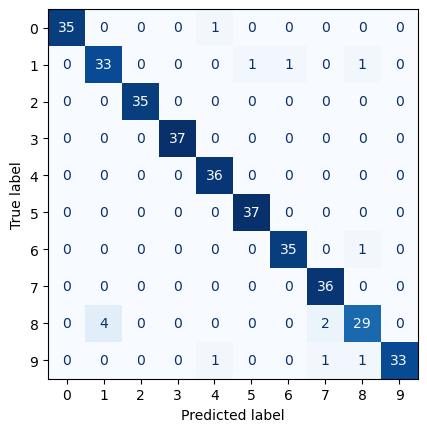

In [1]:
# Block 1: add the matching comment
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Block 2: add the matching comment
digits = load_digits()
X = digits.images.astype("float32") / 16.0
y = digits.target
X_flat = X.reshape(len(X), 64)

# Block 3: add the matching comment
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_flat, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    random_state=42, stratify=y_train_full
)

# Block 4: add the matching comment
logistic_model = LogisticRegression(max_iter=3000, random_state=42)
logistic_model.fit(X_train, y_train)
# Block 5: add the matching comment
lr_validation_accuracy = accuracy_score(y_val, logistic_model.predict(X_val))
# Block 6: add the matching comment
lr_predictions = logistic_model.predict(X_test)
lr_test_accuracy = accuracy_score(y_test, lr_predictions)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Validation accuracy:", round(lr_validation_accuracy, 4))
print("Test accuracy:", round(lr_test_accuracy, 4))
print(classification_report(y_test, lr_predictions))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_predictions, cmap="Blues", colorbar=False
)
plt.show()

Train, validation, test: 1149 288 360
Validation accuracy: 0.9792
Test accuracy: 0.9667
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.94      0.89      0.91        35
           9       0.97      0.92      0.94        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



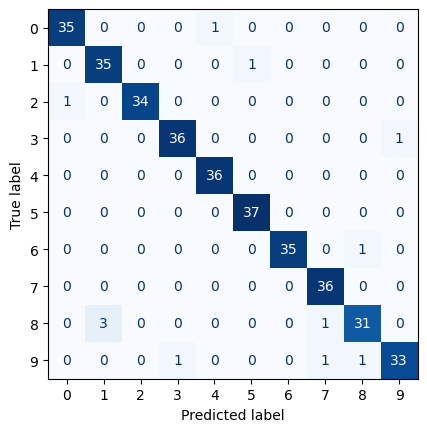

In [2]:
# Block 1: add the matching comment
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Block 2: add the matching comment
digits = load_digits()
X = digits.images.astype("float32") / 16.0
y = digits.target
X_flat = X.reshape(len(X), 64)

# Block 3: add the matching comment
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_flat, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    random_state=42, stratify=y_train_full
)

# Block 4: add the matching comment
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_model.fit(X_train, y_train)
# Block 5: add the matching comment
rf_validation_accuracy = accuracy_score(y_val, rf_model.predict(X_val))
# Block 6: add the matching comment
rf_predictions = rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, rf_predictions)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Validation accuracy:", round(rf_validation_accuracy, 4))
print("Test accuracy:", round(rf_test_accuracy, 4))
print(classification_report(y_test, rf_predictions))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_predictions, cmap="Blues", colorbar=False
)
plt.show()


Train, validation, test: 4800 1200 2000
Features per image: 784


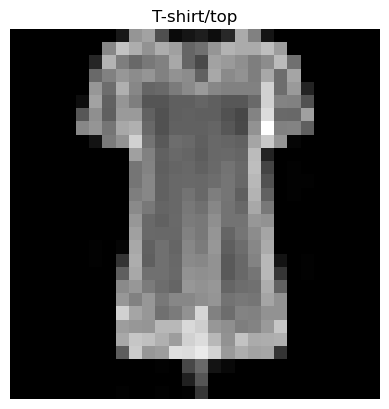

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Load the official training and test sets
(X_pool, y_pool), (X_test_images, y_test) = keras.datasets.fashion_mnist.load_data()

# Use smaller, stratified samples for quicker classroom runs
X_pool, _, y_pool, _ = train_test_split(
    X_pool, y_pool, train_size=6000, random_state=42, stratify=y_pool
)
X_test_images, _, y_test, _ = train_test_split(
    X_test_images, y_test, train_size=2000,
    random_state=42, stratify=y_test
)

# Split training data into training and validation sets
X_train_images, X_val_images, y_train, y_val = train_test_split(
    X_pool, y_pool, test_size=0.20, random_state=42, stratify=y_pool
)

# Scale pixel values from 0–255 to 0–1
X_train_images = X_train_images.astype("float32") / 255.0
X_val_images = X_val_images.astype("float32") / 255.0
X_test_images = X_test_images.astype("float32") / 255.0

# Flatten images for logistic regression and Random Forest
X_train = X_train_images.reshape(len(X_train_images), -1)
X_val = X_val_images.reshape(len(X_val_images), -1)
X_test = X_test_images.reshape(len(X_test_images), -1)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Features per image:", X_train.shape[1])

# Display one example
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.imshow(X_train_images[0], cmap="gray")
plt.title(class_names[y_train[0]])
plt.axis("off")
plt.show()

Train, validation, test: 4800 1200 2000
Validation accuracy: 0.8292
Test accuracy: 0.8145
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       200
           1       0.98      0.93      0.95       200
           2       0.69      0.65      0.67       200
           3       0.83      0.85      0.84       200
           4       0.68      0.73      0.71       200
           5       0.91      0.89      0.90       200
           6       0.57      0.56      0.56       200
           7       0.89      0.91      0.90       200
           8       0.92      0.90      0.91       200
           9       0.90      0.94      0.92       200

    accuracy                           0.81      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.82      0.81      0.81      2000



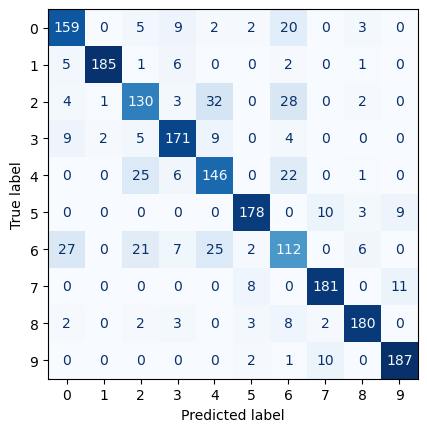

In [4]:
# Block 4: add the matching comment
logistic_model = LogisticRegression(max_iter=3000, random_state=42)
logistic_model.fit(X_train, y_train)
# Block 5: add the matching comment
lr_validation_accuracy = accuracy_score(y_val, logistic_model.predict(X_val))
# Block 6: add the matching comment
lr_predictions = logistic_model.predict(X_test)
lr_test_accuracy = accuracy_score(y_test, lr_predictions)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Validation accuracy:", round(lr_validation_accuracy, 4))
print("Test accuracy:", round(lr_test_accuracy, 4))
print(classification_report(y_test, lr_predictions))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_predictions, cmap="Blues", colorbar=False
)
plt.show()

Train, validation, test: 4800 1200 2000
Validation accuracy: 0.8283
Test accuracy: 0.8325
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       200
           1       1.00      0.93      0.96       200
           2       0.70      0.72      0.71       200
           3       0.81      0.91      0.86       200
           4       0.68      0.76      0.72       200
           5       0.93      0.91      0.92       200
           6       0.68      0.53      0.59       200
           7       0.89      0.89      0.89       200
           8       0.93      0.96      0.95       200
           9       0.88      0.92      0.90       200

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



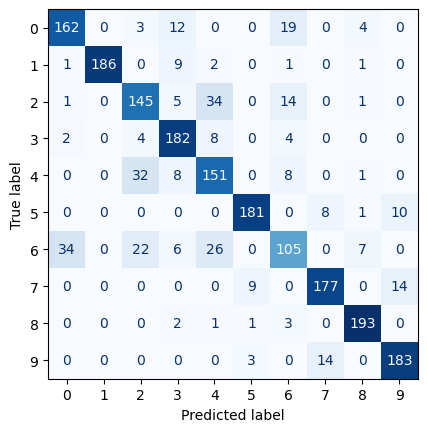

In [5]:
# Block 4: add the matching comment
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_model.fit(X_train, y_train)
# Block 5: add the matching comment
rf_validation_accuracy = accuracy_score(y_val, rf_model.predict(X_val))
# Block 6: add the matching comment
rf_predictions = rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, rf_predictions)

print("Train, validation, test:", len(X_train), len(X_val), len(X_test))
print("Validation accuracy:", round(rf_validation_accuracy, 4))
print("Test accuracy:", round(rf_test_accuracy, 4))
print(classification_report(y_test, rf_predictions))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_predictions, cmap="Blues", colorbar=False
)
plt.show()

In [6]:
# Block 1: add the matching comment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Block 2: add the matching comment
keras.utils.set_random_seed(42)

# Block 3: add the matching comment
(X, y), (X_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Block 4: add the matching comment
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))
print("Official test shape:", X_test_full.shape)

X shape: (60000, 28, 28)
y shape: (60000,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Official test shape: (10000, 28, 28)


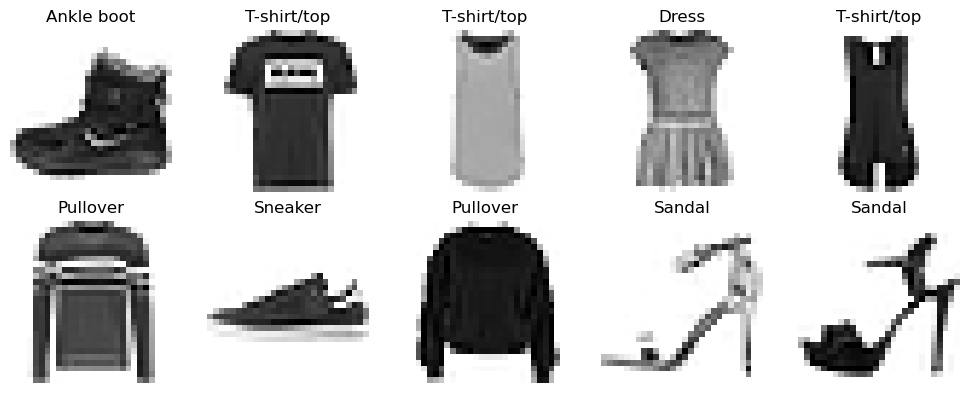

,count
T-shirt/top,6000
Trouser,6000
Pullover,6000
Dress,6000
Coat,6000
Sandal,6000
Shirt,6000
Sneaker,6000
Bag,6000
Ankle boot,6000


In [7]:
# Block 1: add the matching comment
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# Block 2: add the matching comment
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i], cmap="gray_r")
    ax.set_title(class_names[y[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Block 3: add the matching comment
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = [class_names[i] for i in class_counts.index]
display(class_counts.to_frame("count"))

In [8]:
# Block 1: add the matching comment
X_train_full, _, y_train_full, _ = train_test_split(
    X, y, random_state=42, stratify=y
)
X_test, _, y_test, _ = train_test_split(
    X_test_full, y_test_full, train_size=9000,
    random_state=42, stratify=y_test_full
)

# Block 2: add the matching comment
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full,
)

# Block 3: add the matching comment
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Block 4: add the matching comment
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (36000, 28, 28)
Validation: (9000, 28, 28)
Test: (9000, 28, 28)


In [9]:
# Block 1: add the matching comment
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# Block 2: add the matching comment
model.summary()

2026-09-27 07:54:00.844247: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-09-27 07:54:00.844293: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-27 07:54:00.844297: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1790448840.844378   24011 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790448840.844430   24011 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    # Block 1: add the matching comment
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    # Block 2: add the matching comment
    loss="sparse_categorical_crossentropy",
    # Block 3: add the matching comment
    metrics=["accuracy"],
)

In [ ]:
# Block 1: add the matching comment
history = model.fit(
    X_train,
    y_train,
    # Block 2: add the matching comment
    validation_data=(X_val, y_val),
    # Block 3: add the matching comment
    epochs=20,
    batch_size=64,
    verbose=1,
)

Epoch 1/20


2026-09-27 07:54:01.394297: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7759 - loss: 0.6364 - val_accuracy: 0.8141 - val_loss: 0.5304
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8232 - loss: 0.5163 - val_accuracy: 0.8151 - val_loss: 0.5277
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8180 - loss: 0.5469 - val_accuracy: 0.8077 - val_loss: 0.5609
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8099 - loss: 0.6077 - val_accuracy: 0.7591 - val_loss: 0.7963
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7940 - loss: 0.7775 - val_accuracy: 0.7492 - val_loss: 1.1450
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7886 - loss: 0.9214 - val_accuracy: 0.7739 - val_loss: 0.9480
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7782 - loss: 1.1153 - val_accuracy: 0.7729 - val_loss: 1.1630
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7786 - loss: 1.2854 - val_accuracy: 0.772

In [ ]:
# Block 1: add the matching comment
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

# Block 2: add the matching comment
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

Test loss: 1.4479
Test accuracy: 0.7734


Accuracy: 0.7734444444444445
              precision    recall  f1-score   support

 T-shirt/top       0.57      0.84      0.68       900
     Trouser       0.88      0.96      0.92       900
    Pullover       0.83      0.42      0.56       900
       Dress       0.90      0.53      0.67       900
        Coat       0.57      0.77      0.66       900
      Sandal       0.95      0.91      0.93       900
       Shirt       0.55      0.57      0.56       900
     Sneaker       0.90      0.89      0.89       900
         Bag       0.95      0.89      0.92       900
  Ankle boot       0.88      0.97      0.92       900

    accuracy                           0.77      9000
   macro avg       0.80      0.77      0.77      9000
weighted avg       0.80      0.77      0.77      9000



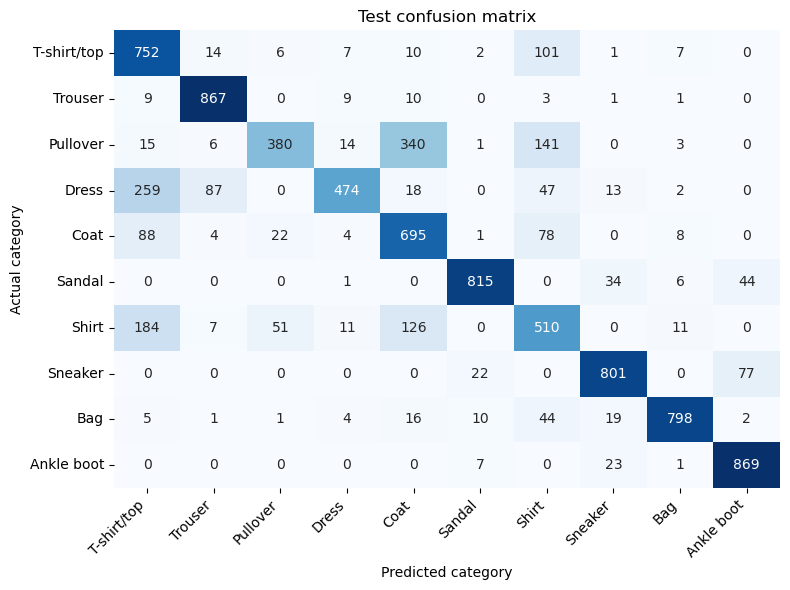

In [ ]:
# Block 1: add the matching comment
probabilities = model.predict(
    X_test,
    verbose=0,
)
y_pred = np.argmax(probabilities, axis=1)

# Block 2: add the matching comment
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Block 3: add the matching comment
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()

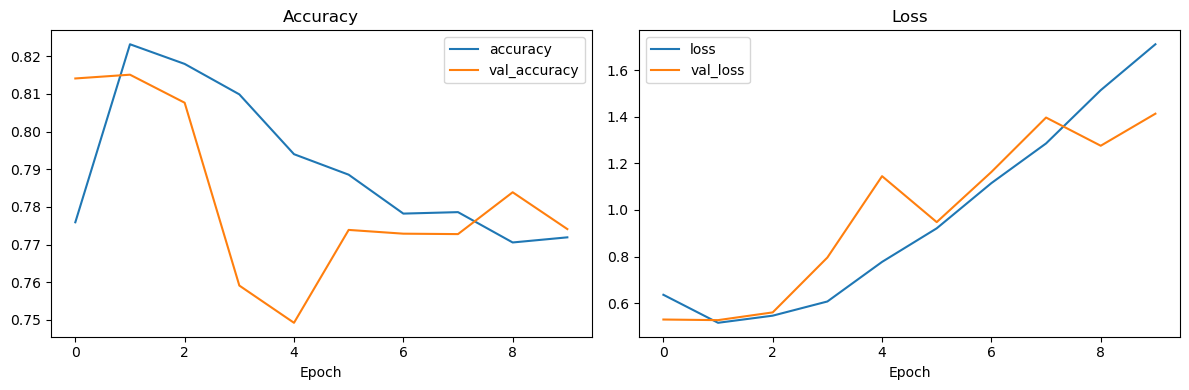

In [ ]:
# Block 1: add the matching comment
history_df = pd.DataFrame(history.history)

# Block 2: add the matching comment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Block 3: add the matching comment
history_df[["accuracy", "val_accuracy"]].plot(
    ax=axes[0],
    title="Accuracy",
)
history_df[["loss", "val_loss"]].plot(
    ax=axes[1],
    title="Loss",
)

# Block 4: add the matching comment
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()